# Downscaling T2

In [1]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import dl4d as dds
#import dl4ds as dds
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import models

2025-06-23 15:20:26.622114: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-23 15:20:26.746822: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/compiler/lib/intel64_lin:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/libfabric/lib:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib/release:/software1/intel/2020_update2/compilers_and_libraries_2020.2.254/linux/mpi/intel64/lib:/software1/intel/2020_

In [2]:
!python --version
#Should be Python 3.8.18

Python 3.7.12


In [3]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [4]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [5]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'


for ds in nam_list:

            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'

In [6]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

# Main training code



Here you can run multiple trainings trying different combinations of predictor variables and architectures.

T2 hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

PSFC hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

T2 lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

PSFC lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 128
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 128
Checking if model has already been tested: ('T2', 'PSFC', 'resnet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', 128, '77', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-23 15:26:08
------------------------------------

21/21 [==============================] - 103s 5s/step - loss: 0.7484 - val_loss: 1.3143
Epoch 2/77
21/21 [==============================] - ETA: 0s - loss: 0.5557

21/21 [==============================] - 87s 4s/step - loss: 0.5557 - val_loss: 0.7132
Epoch 3/77
21/21 [==============================] - ETA: 0s - loss: 0.3755

21/21 [==============================] - 89s 4s/step - loss: 0.3755 - val_loss: 0.3004
Epoch 4/77
21/21 [==============================] - ETA: 0s - loss: 0.3150

21/21 [==============================] - 93s 4s/step - loss: 0.3150 - val_loss: 0.2020
Epoch 5/77
21/21 [==============================] - ETA: 0s - loss: 0.2874

...

21/21 [==============================] - 87s 4s/step - loss: 0.1098 - val_loss: 0.0659
Epoch 42/77
21/21 [==============================] - ETA: 0s - loss: 0.1091

21/21 [==============================] - 88s 4s/step - loss: 0.1091 - val_loss: 0.0656
Epoch 43/77
21/21 [==============================] - ETA: 0s - loss: 0.1090

21/21 [==============================] - 87s 4s/step - loss: 0.1090 - val_loss: 0.0594
Epoch 44/77
21/21 [==============================] - ETA: 0s - loss: 0.1084

21/21 [==============================] - 88s 4s/step - loss: 0.1084 - val_loss: 0.0677
Epoch 45/77
21/21 [==============================] - ETA: 0s - loss: 0.1076

21/21 [==============================] - 89s 4s/step - loss: 0.1076 - val_loss: 0.0660
Epoch 45: early stopping
4/4 [==============================] - 3s 772ms/step - loss: 0.0776

Score on the test set: 0.0775524452328682
--------------------------------------------------------------------------------
Final running time: 1:07:50.379407
--------------------------------------------------------------------------------


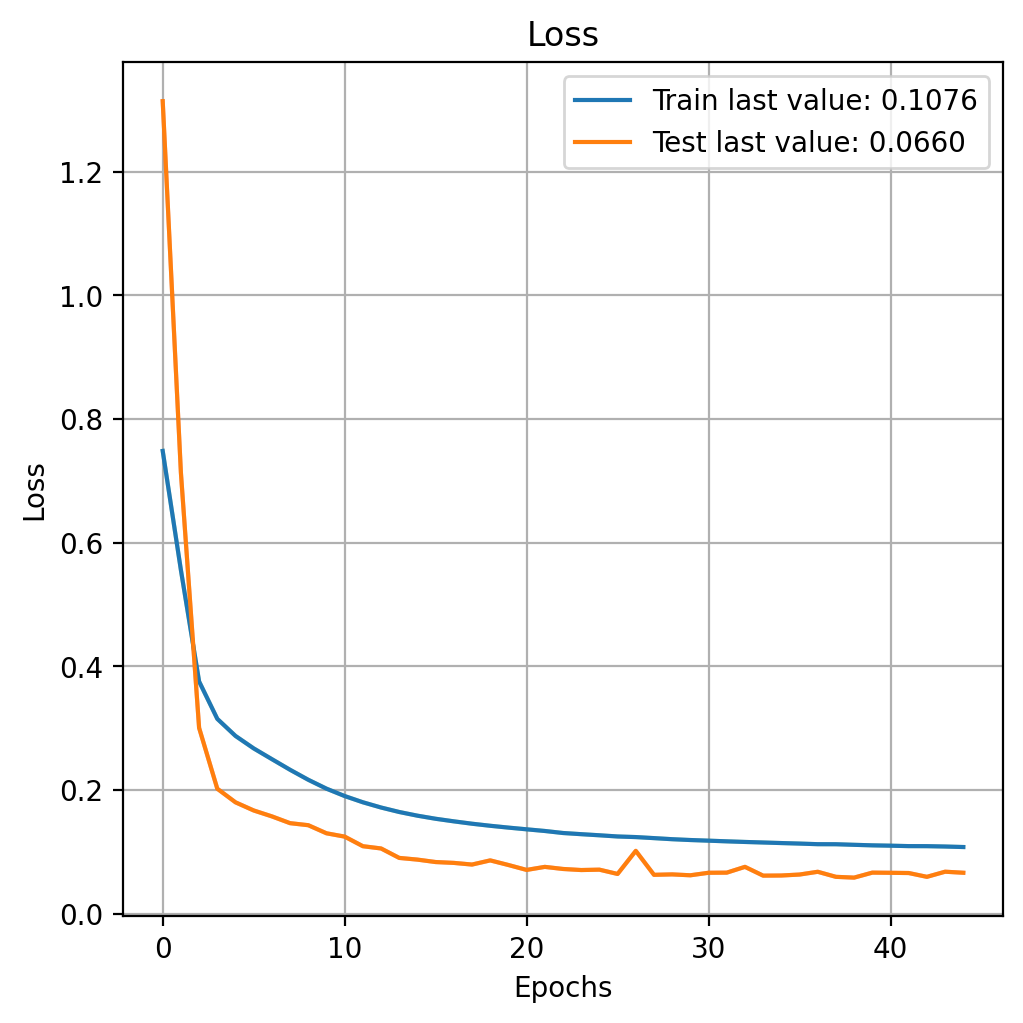

Training complete
T2 hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

WS hr data shape:
(2697, 120, 120, 1) (578, 120, 120, 1) (578, 120, 120, 1)

T2 lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)

WS lr data shape:
(2697, 40, 40, 1) (578, 40, 40, 1) (578, 40, 40, 1)
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 128
Running model with backbone=resnet, filters=8, blocks=8, epochs=77
List of devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Number of devices: 1
Global batch size: 128
Checking if model has already been tested: ('T2', 'WS', 'resnet', '8', '8', '(0.001, 0.0001)', 'inter_area', 'spc', 128, '77', 'mae', 'True', 'True', 'CPU')
--------------------------------------------------------------------------------
Starting time: 2025-06-23 16:34:23
------------------------

21/21 [==============================] - 102s 5s/step - loss: 0.7987 - val_loss: 1.5321
Epoch 2/77
21/21 [==============================] - ETA: 0s - loss: 0.7786

21/21 [==============================] - 93s 4s/step - loss: 0.7786 - val_loss: 1.5311
Epoch 3/77
21/21 [==============================] - ETA: 0s - loss: 0.7662

21/21 [==============================] - 91s 4s/step - loss: 0.7662 - val_loss: 1.5298
Epoch 4/77
21/21 [==============================] - ETA: 0s - loss: 0.7417

21/21 [==============================] - 91s 4s/step - loss: 0.7417 - val_loss: 1.5237
Epoch 5/77
21/21 [==============================] - ETA: 0s - loss: 0.7047

...

21/21 [==============================] - 90s 4s/step - loss: 0.1685 - val_loss: 0.1415
Epoch 26/77
21/21 [==============================] - ETA: 0s - loss: 0.1655

21/21 [==============================] - 88s 4s/step - loss: 0.1655 - val_loss: 0.1257
Epoch 27/77
21/21 [==============================] - ETA: 0s - loss: 0.1628

21/21 [==============================] - 86s 4s/step - loss: 0.1628 - val_loss: 0.1438
Epoch 28/77
21/21 [==============================] - ETA: 0s - loss: 0.1599

21/21 [==============================] - 88s 4s/step - loss: 0.1599 - val_loss: 0.1219
Epoch 29/77
21/21 [==============================] - ETA: 0s - loss: 0.1571

21/21 [==============================] - 90s 4s/step - loss: 0.1571 - val_loss: 0.1386
Epoch 30/77
 5/21 [======>.......................] - ETA: 47s - loss: 0.1525

In [ ]:
####################
## DOWNSCALING T2 ##
####################

var_list = ['T2']
pred_var_list = ['PSFC', 'WS', 'PBLH', 'SWDOWN']

for var in var_list:
    for pred_var in pred_var_list:
        #High resolution (uWRF) data
        var_hr_train = uwrf_train[var]
        var_hr_val = uwrf_val[var]
        var_hr_test = uwrf_test[var]

        pred_var_hr_train = uwrf_train[pred_var]
        pred_var_hr_val = uwrf_val[pred_var]
        pred_var_hr_test = uwrf_test[pred_var]

        #--------------------------
        #Low resolution (NAM) data
        var_lr_train = nam_train[var]
        var_lr_val = nam_val[var]
        var_lr_test = nam_test[var]

        pred_var_lr_train = nam_train[pred_var]
        pred_var_lr_val = nam_val[pred_var]
        pred_var_lr_test = nam_test[pred_var]
        
        var_scaler_train = dds.StandardScaler(axis=None)
        var_scaler_train.fit(var_hr_train)  

        pred_var_scaler_train = dds.StandardScaler(axis=None)
        pred_var_scaler_train.fit(pred_var_hr_train)
        #----------------------------------------------
        #High resolution (uWRF):
        y_train = var_scaler_train.transform(var_hr_train)
        y_val = var_scaler_train.transform(var_hr_val)
        y_test = var_scaler_train.transform(var_hr_test)


        y_z_train = pred_var_scaler_train.transform(pred_var_hr_train)
        y_z_val = pred_var_scaler_train.transform(pred_var_hr_val)
        y_z_test = pred_var_scaler_train.transform(pred_var_hr_test)

        #-------------------------------------------------
        #Low resolution (NAM)

        x_train = var_scaler_train.transform(var_lr_train)
        x_val = var_scaler_train.transform(var_lr_val)
        x_test = var_scaler_train.transform(var_lr_test)

        x_z_train = pred_var_scaler_train.transform(pred_var_lr_train)
        x_z_val = pred_var_scaler_train.transform(pred_var_lr_val)
        x_z_test = pred_var_scaler_train.transform(pred_var_lr_test)
        
        y_train = y_train.expand_dims(dim='channel', axis=-1)
        y_val = y_val.expand_dims(dim='channel', axis=-1)
        y_test = y_test.expand_dims(dim='channel', axis=-1)

        y_z_train = y_z_train.expand_dims(dim ='channel', axis=-1)
        y_z_val = y_z_val.expand_dims(dim ='channel', axis=-1)
        y_z_test = y_z_test.expand_dims(dim ='channel', axis=-1)

        #-----------------------------------------------------

        x_train = x_train.expand_dims(dim='channel', axis=-1)
        x_val = x_val.expand_dims(dim='channel', axis=-1)
        x_test = x_test.expand_dims(dim='channel', axis=-1)

        x_z_train = x_z_train.expand_dims(dim ='channel', axis=-1)
        x_z_val = x_z_val.expand_dims(dim ='channel', axis=-1)
        x_z_test = x_z_test.expand_dims(dim ='channel', axis=-1)
        
        print(f"{var} hr data shape:")
        print(y_train.shape, y_val.shape, y_test.shape)
        print("")
        print(f"{pred_var} hr data shape:")
        print(y_z_train.shape, y_z_val.shape, y_z_test.shape)
        print("")
        print(f"{var} lr data shape:")
        print(x_train.shape, x_val.shape, x_test.shape)
        print("")
        print(f"{pred_var} lr data shape:")
        print(x_z_train.shape, x_z_val.shape, x_z_test.shape)

        
        
        import os
        import shutil
        import csv
        import pandas as pd

        pred_var_train = [y_z_train]
        pred_var_val = [y_z_val]
        pred_var_test = [y_z_test]

        #------------------------------------------------------------------------------------
        results = []
        best_loss = float('inf')
        best_model_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Best-Model" #**change**
        other_models_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Other-Models" #**change**
        test_loss_file = os.path.join(other_models_path, "test_loss.txt")
        runtime_file = os.path.join(other_models_path, "running_time.txt")
        csv_file = f"/home/gvaillant1/downscaling/results/tf_results/{var}_model_results.csv" #**change**
        results = pd.read_csv(csv_file)
        #------------------------------------------------------------------------------------
        #TESTING DIFFERENT HYPER PARAMETERS:
        #change the hyperparams to test different models
        backbones = ['resnet']
        num_filters = [8] 
        num_blocks = [8]
        epochs = [77]
        lrate_values = (1e-3, 1e-4)
        local_layer=True
        #------------------------------------------------------------------------------------

        #Check the existing results csv file to see if the parameter combination has already been tested
        existing_results = []
        if os.path.exists(csv_file):
            with open(csv_file, "r") as f:
                reader = csv.reader(f)
                next(reader, None)  # Skip header
                for row in reader:
                    existing_results.append(tuple(row))

        # Retrieve the lowest loss from CSV before training
        if existing_results:
            best_loss = min(float(row[2]) for row in existing_results if row[2] != "NULL")

        min_losses = {}

        for backbone in backbones:
            for filters in num_filters:
                for blocks in num_blocks:
                    for epoch in epochs:
                        for lr in lrate_values:
                            ARCH_PARAMS = dict(n_filters=filters,
                                               n_blocks=blocks,
                                               normalization=None,
                                               dropout_rate=0.5,
                                               dropout_variant='spatial',
                                               attention=False,
                                               activation='relu',
                                               localcon_layer=local_layer)

                            print(f"Running model with backbone={backbone}, filters={filters}, blocks={blocks}, epochs={epoch}")

                            trainer = dds.SupervisedTrainer(
                                backbone=backbone,
                                upsampling='spc',
                                data_train=y_train,
                                data_val=y_val,
                                data_test=y_test,
                                data_train_lr=None,
                                data_val_lr=None,
                                data_test_lr=None,
                                scale=3,
                                time_window=None,
                                static_vars=None,
                                predictors_train=pred_var_train, #Add predictor information here (not required)
                                predictors_val=pred_var_val, #Add predictor information here (not required)
                                predictors_test=pred_var_test, #Add predictor informatio here (not required)
                                interpolation='inter_area',
                                patch_size=None,
                                batch_size=128,
                                loss='mae',
                                epochs=epoch,
                                steps_per_epoch=None,
                                validation_steps=None,
                                test_steps=None,
                                learning_rate=lr,
                                lr_decay_after=1e4,
                                early_stopping=True,
                                patience=6,
                                min_delta=0,
                                save=True,
                                save_bestmodel=True,
                                save_path=other_models_path,
                                show_plot=True,
                                verbose=True,
                                device='CPU',
                                **ARCH_PARAMS)

                        # Create unique model identifier (ensure all fields match CSV format)
                        #Needed to specify the datatypes so the code will be able to correctly check if we have done the model before
                        model_id = (str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                    backbone, str(filters), str(blocks), str(lrate_values), trainer.interpolation, trainer.batch_size, trainer.upsampling, 
                                    str(trainer.epochs), trainer.loss, str(trainer.early_stopping), str(local_layer), str(trainer.device))

                        model_id = (
                            str(y_train.name),
                            "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                            backbone,
                            str(filters),
                            str(blocks),
                            str(lrate_values),
                            trainer.interpolation,
                            trainer.upsampling,
                            trainer.batch_size,
                            str(trainer.epochs),
                            trainer.loss,
                            str(trainer.early_stopping),
                            str(local_layer),
                            str(trainer.device)
                        )

                        print(f"Checking if model has already been tested: {model_id}")

                        #Check if model already exists in CSV
                        model_exists = False
                        for row in existing_results:
                            existing_model_id = (row[0], row[1], row[3], row[4], row[5], row[11], row[10],
                                                 row[9], row[8], row[6], row[12], row[13], row[16], row[17])
                            #print(f"Comparing with existing model: {existing_model_id}")

                            if existing_model_id == model_id:
                                print("Match found! Skipping training for:", model_id)
                                model_exists = True
                                break

                        if model_exists:
                            continue

                        trainer.run()

                        if os.path.exists(test_loss_file):
                            with open(test_loss_file, "r") as f:
                                val_loss = float(f.read().strip())
                        else:
                            val_loss = float('inf')

                        if os.path.exists(runtime_file):
                            with open(runtime_file, "r") as f:
                                training_runtime = f.read().strip()
                        else:
                            training_runtime = "NULL"

                        model_save_path = other_models_path  # Default save path

                        #Check if the loss we just calculated is the lowest
                        #If so, it is the best model and it should be put in the best model directory


                        #Set the dictionary holding the lowest loss values.
                        #This assumes that the results file has some data in it already
                        for ele in results['Loss Function'].unique():
                            value = results.loc[results['Loss Function'] == ele, 'Test Loss'].values
                            min_losses[ele] = min(value)

                        for key, value in min_losses.items():
                            if trainer.loss == key and val_loss < value:
                                min_losses[trainer.loss] = val_loss

                        #print(min_losses)


                            # Remove previous best model completely before replacing it
                                if os.path.exists(best_model_path):
                                    shutil.rmtree(best_model_path)  # Delete the entire directory

                                # Move new best model to the best model directory
                                shutil.move(other_models_path, best_model_path)
                                model_save_path = best_model_path #replace the model_save_path with the best model path if it has a lower loss
                                print('Moved to best model directory')

                            results = results.append(
                                        pd.DataFrame([[
                                            str(y_train.name), 
                                            "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                            val_loss, 
                                            backbone, 
                                            filters, 
                                            blocks, 
                                            trainer.epochs, 
                                            trainer.model.count_params(), 
                                            trainer.upsampling, 
                                            trainer.interpolation, 
                                            trainer.batch_size, 
                                            lrate_values, 
                                            trainer.loss, 
                                            trainer.early_stopping, 
                                            training_runtime, 
                                            model_save_path, 
                                            local_layer, 
                                            trainer.device
                                        ]], columns=["Downscaled Variable", "Predictor", "Test Loss",
                                                     "Backbone", "Filters", "Blocks",
                                                     "Epochs", "Parameters", "Upsampling Method",
                                                     "Interpolation Method", "Batch Size", "Learning Rate",
                                                     "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                                    )



                        #Write the information about the model and results in the results CSV file
                        file_exists = os.path.isfile(csv_file)
                        with open(csv_file, mode='a', newline='') as f:
                            writer = csv.writer(f)
                            if not file_exists:
                                writer.writerow(["Downscaled Variable", "Predictor", "Test Loss",
                                                 "Backbone", "Filters", "Blocks",
                                                "Epochs", "Parameters", "Upsampling Method",
                                                 "Interpolation Method", "Batch Size", "Learning Rate",
                                                "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"])
                            writer.writerow([str(y_train.name), "NULL" if trainer.predictors_train is None else str(trainer.predictors_train[0].name),
                                             val_loss, backbone, filters, blocks,
                                             trainer.epochs, trainer.model.count_params(), trainer.upsampling,
                                             trainer.interpolation, trainer.batch_size, lrate_values, 
                                             trainer.loss, trainer.early_stopping, training_runtime, model_save_path, local_layer, trainer.device])

        print("Training complete")